# Report figures

In [1]:
here::i_am("rna/mapping/run/mnn/mapping_mnn.R")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

# Load packages
suppressPackageStartupMessages(library(ggrastr))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [7]:
meta = fread(file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_after_qc.txt.gz'))

In [2]:
args = list()
args$sce = file.path(io$basedir, 'results/rna/pseudobulk/celltype_genotype/SingleCellExperiment_pseudobulk_with_replicates.rds')
args$outdir = file.path(io$basedir, 'results/FYR_figures/')

dir.create(args$outdir, showWarnings = F)

In [3]:
meta = fread(file.path(io$basedir, 'results/rna/mapping/sample_metadata_after_mapping.txt.gz'))[!is.na(celltype)]

In [4]:
# atlas
atlas_in = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/'
# plot original atlas projection to make comprehensible
atlas_meta = fread(paste0(atlas_in, 'sample_metadata.txt.gz'))
atlas_meta = atlas_meta[atlas_meta$doublet==FALSE & atlas_meta$stripped==FALSE,]
atlas_umap <- atlas_meta[, c('cell', 'umapX', 'umapY')]
colnames(atlas_umap) <- c('closest.cell', 'umapX.mapped', 'umapY.mapped')
meta_complete <- merge(meta, atlas_umap, by='closest.cell', all.x=TRUE)

In [6]:
#sce = readRDS(args$sce)

In [7]:
umap_theme = theme_void() + 
            theme(panel.border=element_rect(color='black', fill=NA),
            plot.title = element_text(hjust = 0.5),
            text=element_text(size=20),
            legend.position='none')

In [8]:
head(meta_complete)

closest.cell,cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,pass_rnaQC,doublet_score,doublet_call,celltype,celltype.score,day_celltype,celltype_genotype,umapX.mapped,umapY.mapped
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
cell_1000,1A_Eo_DEG_G9_day3#AGGTTTATCTTAGGGT-1,AGGTTTATCTTAGGGT-1,1A_Eo_DEG_G9_day3,3761,8698,4.66,7.38,day3_wt_rep1,D3,wt,TRUE,0.14,FALSE,Primitive_Streak,0.76,D3-wt,Primitive_Streak-wt,-2.9437,-0.7820226
cell_1000,1B_Eo_DEG_G9_day3#AGCTGCTCACCAACCG-1,AGCTGCTCACCAACCG-1,1B_Eo_DEG_G9_day3,3247,6579,3.56,6.34,day3_wt_rep2,D3,wt,TRUE,0.14,FALSE,Primitive_Streak,0.48,D3-wt,Primitive_Streak-wt,-2.9437,-0.7820226
cell_1000,2_Eo_DEG_G9_day3_5_VC#CAACCGGGTTGGATCA-1,CAACCGGGTTGGATCA-1,2_Eo_DEG_G9_day3_5_VC,3870,9785,12.01,9.28,day3.5_wt_rep2,D3.5,wt,TRUE,0.02,FALSE,Primitive_Streak,0.68,D3.5-wt,Primitive_Streak-wt,-2.9437,-0.7820226
cell_1000,2_Eo_DEG_G9_day3_5_VC#CGAACCGGTACAAAGA-1,CGAACCGGTACAAAGA-1,2_Eo_DEG_G9_day3_5_VC,3171,7483,15.84,8.43,day3.5_wt_rep2,D3.5,wt,TRUE,0.01,FALSE,Primitive_Streak,0.60,D3.5-wt,Primitive_Streak-wt,-2.9437,-0.7820226
cell_1000,2_Eo_DEG_G9_day3_5_VC#CTTCAAGCATTAGGTT-1,CTTCAAGCATTAGGTT-1,2_Eo_DEG_G9_day3_5_VC,3644,8871,10.68,8.61,day3.5_wt_rep2,D3.5,wt,TRUE,0.04,FALSE,Primitive_Streak,0.64,D3.5-wt,Primitive_Streak-wt,-2.9437,-0.7820226
cell_1000,2_Eo_DEG_G9_day3_5_VC#GAAGTATAGTTGCCTC-1,GAAGTATAGTTGCCTC-1,2_Eo_DEG_G9_day3_5_VC,5295,16420,10.81,6.38,day3.5_wt_rep2,D3.5,wt,TRUE,1.24,FALSE,Primitive_Streak,0.56,D3.5-wt,Primitive_Streak-wt,-2.9437,-0.7820226


### Atlas UMAP

In [70]:
atlas_labels = atlas_meta %>% .[,`:=`(umapXmean=mean(umapX), umapYmean=mean(umapY)), by=celltype] %>% unique(by='celltype')

In [109]:
p0 = ggplot(atlas_meta[cell %in% sample(cell, 5000)], aes(umapX, umapY, col=celltype)) + 
    geom_point(alpha=0.4, size=0.3) + 
    ggrepel::geom_text_repel(data=atlas_labels, aes(umapXmean, umapYmean, label=celltype), color='black', fontface ='bold', size=3) + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    theme_void() + theme(legend.position='none')

In [134]:
pdf(file.path(args$outdir, '/legend_atlas.pdf'), width=5, height=5)
    rasterize(p0, dpi=600)
dev.off()            

png 
  2

In [138]:
legend = get_legend(ggplot(atlas_meta[cell %in% sample(cell, 5000)], aes(umapX, umapY, col=celltype)) + 
    geom_point(alpha=1, size=5) + guides(col=guide_legend(ncol=3)) + 
    ggrepel::geom_text_repel(data=atlas_labels, aes(umapXmean, umapYmean, label=celltype), color='black', fontface ='bold', size=3) + 
    scale_colour_manual(values = opts$celltype.colors, name = "") +
    theme_void()) 

In [140]:
pdf(file.path(args$outdir, '/legend_celltypes.pdf'), width=8, height=4)
    as_ggplot(legend)
dev.off()            

png 
  2

### Mapping UMAP

In [57]:
p1 = ggplot(meta_complete[day=='D3',], aes(umapX.mapped, umapY.mapped, col=celltype)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.3) + 
    ggtitle('D3 Eomes WT') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme

p2 = ggplot(meta_complete[genotype=='wt' & day!='D3',], aes(umapX.mapped, umapY.mapped, col=celltype)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.3) + 
    ggtitle('Eomes WT') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme

p3 = ggplot(meta_complete[genotype=='eomes_ko',], aes(umapX.mapped, umapY.mapped, col=celltype)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.3) + 
    ggtitle('Eomes KD') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme

p4 = ggplot(meta_complete[genotype=='wt' & day!='D3',], aes(umapX.mapped, umapY.mapped, col=day)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.3) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme

p5 = ggplot(meta_complete[genotype=='eomes_ko',], aes(umapX.mapped, umapY.mapped, col=day)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey90') + 
    geom_point(alpha=0.8, size=0.3) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme

In [55]:
pdf(file.path(args$outdir, '/atlas_mapping_celltype.pdf'), width=15, height=5)
    ggarrange(rasterize(p1, dpi=600), rasterize(p2, dpi=600), rasterize(p3, dpi=600),
              ncol=3)
dev.off()            

png 
  2

In [58]:
pdf(file.path(args$outdir, '/atlas_mapping_day.pdf'), width=15, height=5)
    ggarrange(rasterize(p4, dpi=600), rasterize(p5, dpi=600),
              ncol=3)
dev.off()

png 
  2

In [143]:
legend = get_legend(ggplot(meta_complete, aes(umapX.mapped, umapY.mapped, col=day)) + 
    geom_point(alpha=1, size=5) + guides(col=guide_legend(ncol=1)) + 
    ggrepel::geom_text_repel(data=atlas_labels, aes(umapXmean, umapYmean, label=celltype), color='black', fontface ='bold', size=3) + 
    scale_colour_manual(values = opts$days.colors, name = "") +
    theme_void()) 
pdf(file.path(args$outdir, '/legend_days.pdf'), width=2, height=2)
    as_ggplot(legend)
dev.off()            

png 
  2

png 
  2

# RNA & ATAC UMAPs

In [36]:
RNA_UMAP = fread(paste0(io$basedir, '/results/rna/dimensionality_reduction/sce/batch_correction_None/umap_features2500_pcs50_neigh25_dist0.5.txt.gz'))
RNA_UMAP = merge(meta, RNA_UMAP, by='cell')

ATAC_UMAP = fread(paste0(io$basedir, '/results/atac/archR/dimensionality_reduction/cells/PeakMatrix_atlas/remove_ExE_cells_FALSE/batch_correction_None/umap_nfeatures25000_dims25_nneighbour25_mindist0.5.txt.gz'))
ATAC_UMAP = merge(meta, ATAC_UMAP, by='cell')

In [61]:
p1 = ggplot(RNA_UMAP[genotype=='wt' & day=='D3'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(RNA_UMAP$UMAP1), max(RNA_UMAP$UMAP1)) + 
    ylim(min(RNA_UMAP$UMAP2), max(RNA_UMAP$UMAP2)) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p2 = ggplot(RNA_UMAP[genotype=='wt' & day!='D3'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(RNA_UMAP$UMAP1), max(RNA_UMAP$UMAP1)) + 
    ylim(min(RNA_UMAP$UMAP2), max(RNA_UMAP$UMAP2)) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p3 = ggplot(RNA_UMAP[genotype=='eomes_ko'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(RNA_UMAP$UMAP1), max(RNA_UMAP$UMAP1)) + 
    ylim(min(RNA_UMAP$UMAP2), max(RNA_UMAP$UMAP2)) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p4 = ggplot(RNA_UMAP[genotype=='wt' & day!='D3'] , aes(UMAP1, UMAP2, col=day)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(RNA_UMAP$UMAP1), max(RNA_UMAP$UMAP1)) + 
    ylim(min(RNA_UMAP$UMAP2), max(RNA_UMAP$UMAP2)) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme
p5 = ggplot(RNA_UMAP[genotype=='eomes_ko'] , aes(UMAP1, UMAP2, col=day)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(RNA_UMAP$UMAP1), max(RNA_UMAP$UMAP1)) + 
    ylim(min(RNA_UMAP$UMAP2), max(RNA_UMAP$UMAP2)) + 
    ggtitle('') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme

In [62]:
pdf(file.path(args$outdir, '/RNA_umap.pdf'), width=25, height=5)
    ggarrange(rasterize(p1, dpi=600), rasterize(p2, dpi=600), rasterize(p3, dpi=600), rasterize(p4, dpi=600), rasterize(p5, dpi=600),
              ncol=5)
dev.off()            

png 
  2

In [43]:
ATAC_UMAP = ATAC_UMAP %>% setnames(c('umap1', 'umap2'), c('UMAP1', 'UMAP2'))

In [59]:
p1 = ggplot(ATAC_UMAP[genotype=='wt' & day=='D3'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(ATAC_UMAP$UMAP1), max(ATAC_UMAP$UMAP1)) + 
    ylim(min(ATAC_UMAP$UMAP2), max(ATAC_UMAP$UMAP2)) + 
    ggtitle('D3 Eomes WT') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p2 = ggplot(ATAC_UMAP[genotype=='wt' & day!='D3'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(ATAC_UMAP$UMAP1), max(ATAC_UMAP$UMAP1)) + 
    ylim(min(ATAC_UMAP$UMAP2), max(ATAC_UMAP$UMAP2)) + 
    ggtitle('Eomes WT') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p3 = ggplot(ATAC_UMAP[genotype=='eomes_ko'] , aes(UMAP1, UMAP2, col=celltype)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(ATAC_UMAP$UMAP1), max(ATAC_UMAP$UMAP1)) + 
    ylim(min(ATAC_UMAP$UMAP2), max(ATAC_UMAP$UMAP2)) + 
    ggtitle('Eomes KD') + 
    scale_colour_manual(values = opts$celltype.colors, name = "celltype") +
    umap_theme
p4 = ggplot(ATAC_UMAP[genotype=='wt' & day!='D3'] , aes(UMAP1, UMAP2, col=day)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(ATAC_UMAP$UMAP1), max(ATAC_UMAP$UMAP1)) + 
    ylim(min(ATAC_UMAP$UMAP2), max(ATAC_UMAP$UMAP2)) + 
    ggtitle('Eomes WT') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme
p5 = ggplot(ATAC_UMAP[genotype=='eomes_ko'] , aes(UMAP1, UMAP2, col=day)) + 
    geom_point(alpha=0.8, size=0.3) + 
    xlim(min(ATAC_UMAP$UMAP1), max(ATAC_UMAP$UMAP1)) + 
    ylim(min(ATAC_UMAP$UMAP2), max(ATAC_UMAP$UMAP2)) + 
    ggtitle('Eomes KD') + 
    scale_colour_manual(values = opts$days.colors, name = "celltype") +
    umap_theme

In [60]:
pdf(file.path(args$outdir, '/ATAC_umap.pdf'), width=25, height=5)
    ggarrange(rasterize(p1, dpi=600), rasterize(p2, dpi=600), rasterize(p3, dpi=600), rasterize(p4, dpi=600), rasterize(p5, dpi=600),
              ncol=5)
dev.off()            

png 
  2

# DEGs

In [159]:
DEGs = fread(file.path(io$basedir, 'results/rna/differential/DEGs.txt.gz')) %>%
    .[,sig:=ifelse(abs(logFC)>1 & padj_fdr<0.05, 'TRUE', 'FALSE')]

In [160]:
head(DEGs)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
,NA,NA,NA,NA,Epiblast,NA
Hspd1,-0.700,1.06e-28,10.87,10.16,Primitive_Streak,FALSE
Fat3,-2.694,4.60e-27,8.29,5.60,Primitive_Streak,TRUE
Rplp1,0.507,4.60e-27,10.41,10.91,Primitive_Streak,FALSE
Rps3,0.477,4.60e-27,10.42,10.89,Primitive_Streak,FALSE
Aldoa,1.199,6.70e-27,7.70,8.89,Primitive_Streak,TRUE


In [181]:
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=10, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = DEGs[celltype == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  to.plot = to.plot[,logFC:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))]
    
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*0.9), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim)) +
    annotate("text", x=0, y=ylim*0.95, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim+1, y=ylim*0.95, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim-1, y=ylim*0.95, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(rasterize(p, dpi=600))
}

In [182]:
for(i in unique(DEGs$celltype)){
    p = gg_volcano_plot(i, xlim=3, top_genes=15)
    ct = gsub("/", "_", i)
    pdf(sprintf('%s/results/rna/differential/DEGs_%s.pdf', io$basedir, ct), width=8, height=8)
         print(p)
    dev.off()
}

# DARs

In [6]:
DARs = fread(file.path(io$basedir, 'results/atac/archR/differential/DARs.txt.gz'))

In [7]:
DARs = DARs %>% 
    .[,sig:=ifelse(abs(logFC)>0.5 & padj_fdr<0.05, TRUE, FALSE)] %>%
    .[,direction:=ifelse(logFC>0, 'up', 'down')] 

In [8]:
head(DARs)

logFC,Mean,padj_fdr,Pval,MeanDiff,MeanBGD,idx,feature,celltype,sig,direction
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<lgl>,<chr>
NA,NA,NA,NA,NA,NA,NA,,Epiblast,NA,NA
-0.01041662,0.4707904,0.98829040,0.952278507,-0.003436426,0.4742268,4,chr1:3670521-3671121,Primitive_Streak,FALSE,down
-0.18511141,0.5738832,0.06314989,0.007135957,-0.079037801,0.6529210,5,chr1:3671476-3672076,Primitive_Streak,FALSE,down
-0.07400058,0.2577320,0.84893288,0.633059485,-0.013745704,0.2714777,6,chr1:3672269-3672869,Primitive_Streak,FALSE,down
-0.22239242,0.1615120,0.51561607,0.234791543,-0.027491409,0.1890034,7,chr1:3681367-3681967,Primitive_Streak,FALSE,down
-0.30932806,0.3127148,0.06499522,0.007465667,-0.075601375,0.3883162,21,chr1:4491824-4492424,Primitive_Streak,FALSE,down


In [9]:
ct_keep = c( 'Primitive_Streak', 'Nascent_mesoderm', 'Mixed_mesoderm', 'ExE_mesoderm', 'Haematoendothelial_progenitors',  'Allantois','Endothelium','Intermediate_mesoderm',  'Mesenchyme')

In [10]:
DAR_stats = DARs[sig==TRUE] %>% 
    .[,N:=.N, by=c('celltype','direction')] %>%  unique(by=c('celltype','direction')) %>%
    .[celltype %in% ct_keep] %>%
    .[,celltype:=factor(celltype, levels=ct_keep)]

In [11]:
options(repr.plot.width = 15,repr.plot.height = 5)
p = ggplot(DAR_stats, aes(celltype, N, fill=direction)) +
    geom_bar(stat='identity', position='dodge') +
    scale_fill_manual(values=c('up'='burlywood', 'down'='cadetblue')) + 
    ylab('Number of peaks') + 
    theme_bw() + 
    theme(text=element_text(size=15),
          axis.text=element_text(color='black'),
          axis.text.x=element_text(angle=-25, hjust=0, vjust=1),
          axis.title.x=element_blank())

In [13]:
pdf(sprintf('%s/results/atac/archR/differential/DAR_stats.pdf', io$basedir), width=8, height=4)
     print(p)
dev.off()

png 
  2

In [238]:
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=10, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = DARs[celltype == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,feature]
  positive_hits <- to.plot[sig==TRUE & logFC>0,feature]
  all <- nrow(to.plot)
  to.plot = to.plot[,logFC:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))]
    
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, feature],n=top_genes), head(to.plot[sig==T & logFC>=0, feature],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*0.9), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim)) +
    annotate("text", x=0, y=ylim*0.95, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim+1, y=ylim*0.95, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim-1, y=ylim*0.95, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[feature %in% label_genes],
                                    aes(x=logFC, y=-log10(padj_fdr+1e-100), label=feature), max.overlaps=Inf, size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(rasterize(p, dpi=600))
}

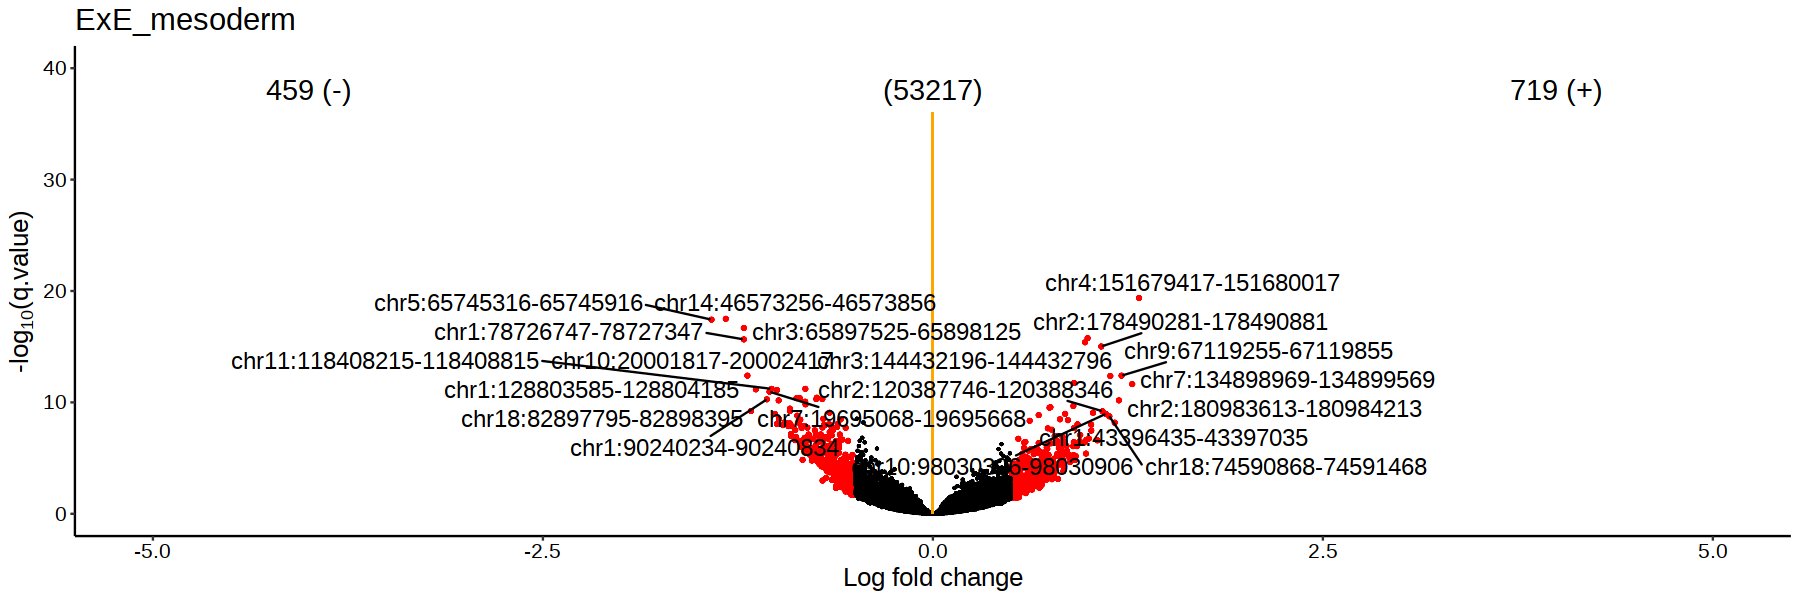

In [240]:
gg_volcano_plot('ExE_mesoderm')